In [1]:
import sys
from pathlib import Path

import glob
import pickle
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from matplotlib.colors import LogNorm
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cmocean as cmc

import importlib
import xarray as xr


plt.style.use('../plotstyling.mplstyle')

sys.path.insert(0, str(Path.cwd().parent / "scripts"))

import plot_utils

In [2]:
with open("../../../DataStorage/AWS/Arctic/arctic_trainings/AWS_test_set_retrievals_arctic_2026-04-17.pickle", 'rb') as file:
    retrieval_dict = pickle.load(file)
    
with open("../../../DataStorage/AWS/Arctic/arctic_trainings/AWS_test_set_retrievals_arctic_2026-04-17_on_training_set.pickle", 'rb') as file:
    retrieval_dict_train = pickle.load(file)

In [3]:
fwp_bins = np.concatenate([
    [0],
    np.logspace(np.log10(1e-3), np.log10(1e2), 100),
])
lwp_bins = np.concatenate([
    [0],
    np.logspace(np.log10(1e-3), np.log10(1e1), 100),
])
zm_bins = np.linspace(0, 9000, 50)
dm_bins = np.linspace(0, 0.0015, 50)
lat_bins = np.linspace(-70, 70, 70)

units = {
    "fwp": "kg m$^{-2}$",
    "iwc": "kg m$^{-3}$",
    "zm": "km",
    "dm": "$\mu$m",
    "slwp": "kg m$^{-2}$",
}

fwp_true = retrieval_dict["fwp_true"]
fwp_pred = retrieval_dict["fwp_mean"]


# filtering for zm and dm
fwp_sensitivity_idxs = np.where(retrieval_dict["fwp_true"] > 1e-2)[0]
fwp_sensitivity_idxs_20260928 = np.where(retrieval_dict["fwp_true"] > 1e-2)[0]

high_true_fwp_idxs = np.where(retrieval_dict["fwp_true"] > 5e0)[0]
high_fwp_true = retrieval_dict["fwp_true"][high_true_fwp_idxs]
high_fwp_pred = retrieval_dict["fwp_mean"][high_true_fwp_idxs]

lat = retrieval_dict["latitude"]
#lon = retrieval_dict["longitude"]

In [4]:
retrieval_dict

{'fwp_true': array([0.01745267, 0.03290381, 0.02516443, ..., 0.58254681, 1.17072109,
        0.5216962 ]),
 'lwp_true': array([0.0646386 , 0.0637276 , 0.06522948, ..., 0.2143783 , 0.20942633,
        0.19873599]),
 'zm_true': array([ 514.25426272,  533.90786335,  539.5901603 , ..., 3116.76804247,
        3817.73222659, 3421.78753919]),
 'dm_true': array([0.00032128, 0.00034946, 0.00035263, ..., 0.00051881, 0.00054572,
        0.00048805]),
 'latitude': array([69.43485953, 69.50760955, 69.58031213, ..., 75.68161811,
        75.74670241, 75.81164725]),
 'fwp_mean': array([0.05332708, 0.04098031, 0.05449661, ..., 0.08418239, 0.03383731,
        0.92820591]),
 'lwp_mean': array([0.053818  , 0.05997681, 0.0571096 , ..., 0.21571112, 0.00836371,
        0.19263633]),
 'zm_mean': array([3252.43766355, 3636.9961451 , 2979.43492114, ..., 3208.48797416,
        7374.77136597, 3018.21384949]),
 'dm_mean': array([0.0003304 , 0.00034596, 0.00034877, ..., 0.0004667 , 0.00071674,
        0.00059127]),

(0.0, 12.0)

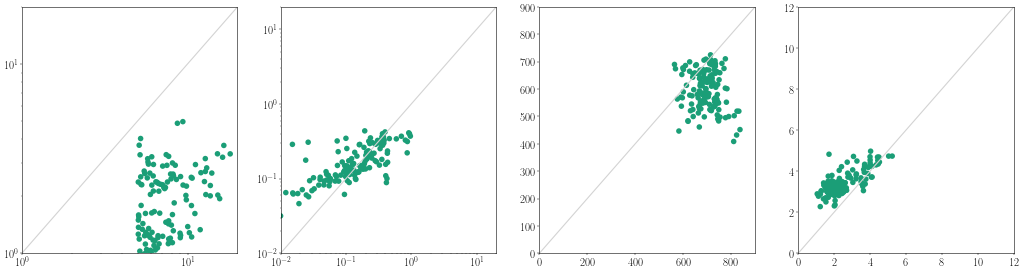

In [5]:
fig, axes = plt.subplots(1, 4, figsize=(32,8))


axes[0].scatter(high_fwp_true, high_fwp_pred)
axes[0].plot([1e0, 20], [1e0, 20], lw=2, c="lightgrey")
axes[0].set_xlim([1e0, 20])
axes[0].set_ylim([1e0, 20])
axes[0].set_xscale("log")
axes[0].set_yscale("log")

axes[1].scatter(retrieval_dict['lwp_true'][high_true_fwp_idxs], retrieval_dict['lwp_mean'][high_true_fwp_idxs])
axes[1].plot([1e-2, 20], [1e-2, 20], lw=2, c="lightgrey")
axes[1].set_xlim([1e-2, 20])
axes[1].set_ylim([1e-2, 20])
axes[1].set_xscale("log")
axes[1].set_yscale("log")

axes[2].scatter(retrieval_dict['dm_true'][high_true_fwp_idxs]/1e-6, retrieval_dict['dm_mean'][high_true_fwp_idxs]/1e-6)
axes[2].plot([0, 900], [0, 900], lw=2, c="lightgrey")
axes[2].set_xlim([0, 900])
axes[2].set_ylim([0, 900])

axes[3].scatter(retrieval_dict['zm_true'][high_true_fwp_idxs]/1e3, retrieval_dict['zm_mean'][high_true_fwp_idxs]/1e3)
axes[3].plot([0, 12], [0, 12], lw=2, c="lightgrey")
axes[3].set_xlim([0, 12])
axes[3].set_ylim([0, 12])

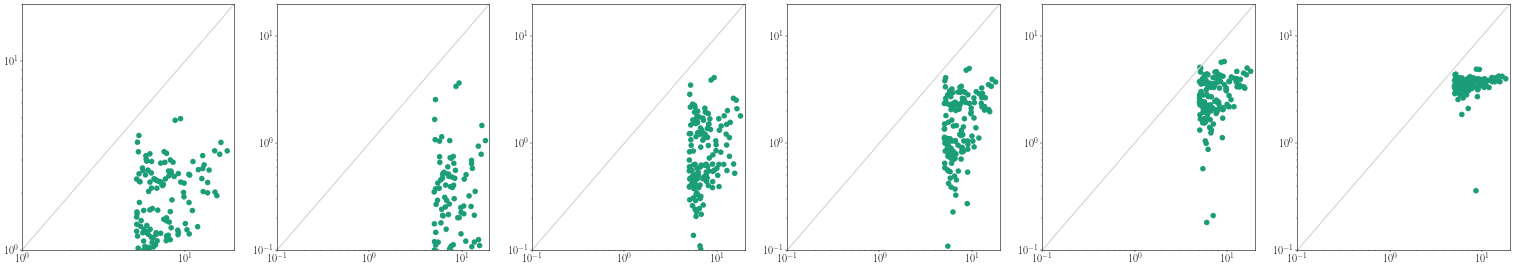

In [6]:
fig, axes = plt.subplots(1, 6, figsize=(48,8))


axes[0].scatter(high_fwp_true, high_fwp_pred)
axes[0].plot([1e0, 20], [1e0, 20], lw=2, c="lightgrey")
axes[0].set_xlim([1e0, 20])
axes[0].set_ylim([1e0, 20])
axes[0].set_xscale("log")
axes[0].set_yscale("log")


for i, col in enumerate([0, 15, 49, 83, 98]):
    ax  = axes[i+1]
    ax.scatter(high_fwp_true, retrieval_dict["fwp_quantiles"][high_true_fwp_idxs][:,col])
    ax.plot([1e-1, 20], [1e-1, 20], lw=2, c="lightgrey")
    ax.set_xlim([1e-1, 20])
    ax.set_ylim([1e-1, 20])
    ax.set_xscale("log")
    ax.set_yscale("log")

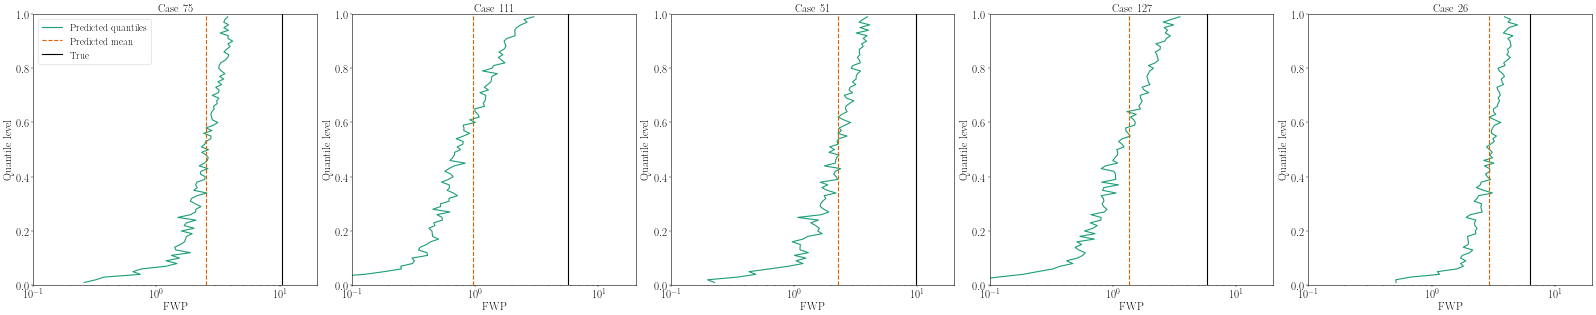

In [7]:
rng = np.random.default_rng()
quantiles = retrieval_dict["fwp_quantiles"][high_true_fwp_idxs]
sample = rng.choice(len(high_fwp_true), size=5, replace=False)
tau = np.linspace(0.01, 0.99, 99)  # quantile levels

fig, axes = plt.subplots(1, 5, figsize=(40, 8))

for ax, j in zip(axes, sample):
    ax.plot(quantiles[j], tau, lw=2, c="C0", label="Predicted quantiles")
    ax.axvline(high_fwp_pred[j], c="C1", ls="--", lw=2, label="Predicted mean")
    ax.axvline(high_fwp_true[j], c="k", lw=2, label="True")
    ax.set_xscale("log")
    ax.set_xlim([1e-1, 20])
    ax.set_ylim([0, 1])
    ax.set_xlabel("FWP")
    ax.set_ylabel("Quantile level")
    ax.set_title(f"Case {j}")

axes[0].legend()
plt.tight_layout()

'\nplt.savefig("../figures/test_set_retrievals/AWS_FWP_distribution_arctic.pdf", facecolor="white")\nplt.savefig("../figures/test_set_retrievals/AWS_FWP_distribution_arctic.png", dpi=400, facecolor="white")\n'

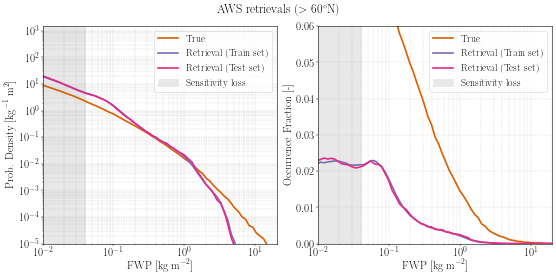

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))

bins_centre = fwp_bins[:-1] + np.diff(fwp_bins) / 2

database_pdf, _ = np.histogram(retrieval_dict_train["fwp_true"], bins=fwp_bins, density=True)
pred_pdf_train, _     = np.histogram(retrieval_dict_train["fwp_mean"], bins=fwp_bins, density=True)
pred_pdf_test, _     = np.histogram(retrieval_dict["fwp_mean"], bins=fwp_bins, density=True)


ax1.plot(bins_centre, database_pdf, color="C1", label="True")
ax1.plot(bins_centre, pred_pdf_train,     color="C2", label="Retrieval (Train set)")
ax1.plot(bins_centre, pred_pdf_test,     color="C3", label="Retrieval (Test set)")
ax1.set_xscale("log")
ax1.set_yscale("log")
ax1.set_ylim(bottom=1e-5)
ax1.set_xlim([1e-2, 2e1])
ax1.set_xticks([1e-2, 1e-1, 1e0, 1e1])
ax1.set_ylabel(r"Prob. Density [$\mathrm{kg}^{-1} \; \mathrm{m}^{2}$]")
ax1.set_xlabel(r"FWP [$\mathrm{kg \; m}^{-2}$]")
ax1.grid(which="both", ls="dashed", color="grey", alpha=0.3)

# ── Occurrence fraction / PMF ─────────────────────────────────────────────────
true_counts, _ = np.histogram(retrieval_dict_train["fwp_true"], bins=fwp_bins)
pred_counts_train, _ = np.histogram(retrieval_dict_train["fwp_mean"], bins=fwp_bins)
pred_counts_test, _ = np.histogram(retrieval_dict["fwp_mean"], bins=fwp_bins)


# total counts INCLUDING zeros
true_total = len(retrieval_dict["fwp_true"])
pred_total_train = len(retrieval_dict_train["fwp_mean"])
pred_total_test = len(retrieval_dict["fwp_mean"])


true_pmf = true_counts / true_total   # now sums to < 1 if zeros exist
pred_pmf_train = pred_counts_train / pred_total_train
pred_pmf_test = pred_counts_test / pred_total_test

ax2.plot(bins_centre, true_pmf, color="C1", label="True")
ax2.plot(bins_centre, pred_pmf_train, color="C2", label="Retrieval (Train set)")
ax2.plot(bins_centre, pred_pmf_test, color="C3", label="Retrieval (Test set)")
ax2.set_xscale("log")
#ax2.set_yscale("log")
ax2.set_ylim([0, 0.06])
ax2.set_xlim([1e-2, 2e1])
ax2.set_xticks([1e-2, 1e-1, 1e0, 1e1])
ax2.set_ylabel("Occurrence Fraction [-]")
ax2.set_xlabel(r"FWP [$\mathrm{kg \; m}^{-2}$]")
ax2.grid(which="both", ls="dashed", color="grey", alpha=0.3)

for ax in (ax1, ax2):
    ax.axvspan(1e-4, 4e-2, color="lightgrey", alpha=0.5, zorder=0, label="Sensitivity loss")

ax1.legend(loc="upper right")
ax2.legend(loc="upper right")

fig.suptitle("AWS retrievals ($>$ 60$^{\circ}$N)", fontsize=22)
fig.tight_layout()
"""
plt.savefig("../figures/test_set_retrievals/AWS_FWP_distribution_arctic.pdf", facecolor="white")
plt.savefig("../figures/test_set_retrievals/AWS_FWP_distribution_arctic.png", dpi=400, facecolor="white")
"""

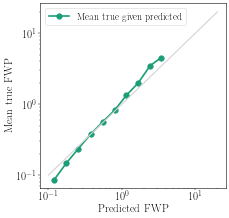

In [9]:
bins = np.logspace(-1, np.log10(20), 15)
which = np.digitize(fwp_pred, bins)
centers, mean_true, mean_pred = [], [], []
for b in range(1, len(bins)):
    m = which == b
    if m.sum() > 10:
        mean_pred.append(fwp_pred[m].mean())
        mean_true.append(fwp_true[m].mean())

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(mean_pred, mean_true, "o-", label="Mean true given predicted")
ax.plot([1e-1, 20], [1e-1, 20], c="lightgrey", lw=2)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Predicted FWP")
ax.set_ylabel("Mean true FWP")
ax.legend()

Text(0, 0.5, 'Count')

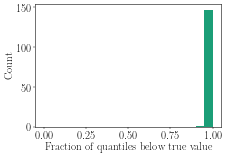

In [10]:
q = retrieval_dict["fwp_quantiles"][high_true_fwp_idxs]
pit = (q < high_fwp_true[:, None]).mean(axis=1)

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(pit, bins=20, range=(0, 1))
ax.set_xlabel("Fraction of quantiles below true value")
ax.set_ylabel("Count")

Using files: ['/home/eleanor/Documents/Research/PHD/Projects/AWS_Arctic/data/training/loss_history_20261001_164336.pkl']
High FWP samples per epoch (train, val): 6238 1047


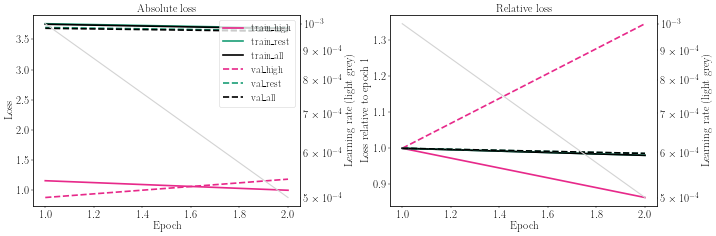

In [13]:
# Load the two most recent history files (one per training stage)
files = sorted(glob.glob("/home/eleanor/Documents/Research/PHD/Projects/AWS_Arctic/data/training/loss_history_*.pkl"))[-2:]
print("Using files:", files)

hist = {}
stage_lengths = []
for fn in files:
    with open(fn, "rb") as f:
        h = pickle.load(f)
    stage_lengths.append(len(h["lr"]))
    for k, v in h.items():
        if isinstance(v, list):
            hist.setdefault(k, []).extend(v)

hist = {k: np.array(v, dtype=float) for k, v in hist.items()}
epochs = np.arange(1, len(hist["lr"]) + 1)
stage_bounds = np.cumsum(stage_lengths)[:-1] + 0.5

# Overall loss as a sample-weighted combination of high and rest
for split in ["train", "val"]:
    n_high = hist[f"n_{split}_high"]
    n_rest = hist[f"n_{split}_rest"]
    hist[f"{split}_all"] = (
        hist[f"{split}_high"] * n_high + hist[f"{split}_rest"] * n_rest
    ) / (n_high + n_rest)

print("High FWP samples per epoch (train, val):",
      int(hist["n_train_high"][0]), int(hist["n_val_high"][0]))

curves = {
    "train_high": ("C3", "-"),
    "train_rest": ("C0", "-"),
    "train_all": ("k", "-"),
    "val_high": ("C3", "--"),
    "val_rest": ("C0", "--"),
    "val_all": ("k", "--"),
}

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Left: absolute loss
ax = axes[0]
for name, (c, ls) in curves.items():
    ax.plot(epochs, hist[name], c=c, ls=ls, label=name)
#ax.set_yscale("log")
ax.set_ylabel("Loss")
ax.set_title("Absolute loss")

# Right: loss relative to epoch 1, to compare shapes
ax = axes[1]
for name, (c, ls) in curves.items():
    ax.plot(epochs, hist[name] / hist[name][0], c=c, ls=ls, label=name)
#ax.set_yscale("log")
ax.set_ylabel("Loss relative to epoch 1")
ax.set_title("Relative loss")

for ax in axes:
    ax.set_xlabel("Epoch")
    for b in stage_bounds:
        ax.axvline(b, c="grey", ls=":", lw=1)
    ax2 = ax.twinx()
    ax2.plot(epochs, hist["lr"], c="lightgrey", lw=2, zorder=0)
    ax2.set_yscale("log")
    ax2.set_ylabel("Learning rate (light grey)")

axes[0].legend(loc="upper right")
plt.tight_layout()
plt.savefig("loss_history_high_vs_rest.png", dpi=150)
plt.show()